In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/finale.csv')

In [3]:
df.head()

,country,countryiso3code,date,gdp_growth,inf,ump,pop,exports,imports,fdi,capital,govt
0,High income,NaN,2025,1.907335,2.348988,4.406735,0.409175,31.746857,30.816793,NaN,NaN,NaN
1,High income,NaN,2024,1.969484,2.381584,4.369003,0.692671,31.449701,30.212457,1.463148,22.643954,17.482548
2,High income,NaN,2023,1.795346,4.731513,4.336579,0.720615,31.831108,30.738089,0.760389,23.018492,17.300274
3,High income,NaN,2022,3.105861,7.531078,4.509680,0.445759,33.695378,32.745573,1.981384,23.629061,17.318772
4,High income,NaN,2021,5.971113,2.518371,5.563413,-0.119156,31.156935,29.875616,2.774648,23.119344,18.140825


In [4]:
df['country'].nunique()

222

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14652 entries, 0 to 14651
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          14652 non-null  object 
 1   countryiso3code  14322 non-null  object 
 2   date             14652 non-null  int64  
 3   gdp_growth       11659 non-null  float64
 4   inf              9319 non-null   float64
 5   ump              6671 non-null   float64
 6   pop              14333 non-null  float64
 7   exports          9249 non-null   float64
 8   imports          9258 non-null   float64
 9   fdi              9427 non-null   float64
 10  capital          8874 non-null   float64
 11  govt             8950 non-null   float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1.3+ MB


In [6]:
df.isna().sum() # To check for mssing values.

country               0
countryiso3code     330
date                  0
gdp_growth         2993
inf                5333
ump                7981
pop                 319
exports            5403
imports            5394
fdi                5225
capital            5778
govt               5702
dtype: int64

In [7]:
(df.isna().sum()/len(df))*100  #Percentage of missing values.

country             0.000000
countryiso3code     2.252252
date                0.000000
gdp_growth         20.427245
inf                36.397761
ump                54.470379
pop                 2.177177
exports            36.875512
imports            36.814087
fdi                35.660661
capital            39.434889
govt               38.916189
dtype: float64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe() 

,date,gdp_growth,inf,ump,pop,exports,imports,fdi,capital,govt
count,14652.000000,11659.000000,9319.000000,6671.000000,14333.000000,9249.000000,9258.000000,9427.000000,8874.000000,8950.000000
mean,1992.500000,3.633351,22.159772,8.026761,1.717573,36.059568,41.459688,5.381894,23.345439,16.378815
std,19.051022,6.678468,313.315480,6.025115,1.787670,28.597191,27.357000,43.867684,8.727360,8.207770
min,1960.000000,-64.047107,-17.640424,0.100000,-27.470786,0.000000,0.000000,-1303.108267,-15.678444,0.000000
25%,1976.000000,1.233651,2.138002,3.680500,0.650258,18.056421,23.761600,0.388833,18.181391,11.299225
50%,1992.500000,3.761454,4.728173,6.277638,1.650466,28.866381,34.321703,1.583079,22.741887,15.295227
75%,2009.000000,6.213568,9.932275,10.829000,2.632579,45.629244,52.868171,3.989114,27.660887,19.531188
max,2025.000000,149.972963,23773.131774,38.800000,21.700343,433.836004,429.359095,1709.827232,76.782325,147.735004


In [10]:
df.corr(numeric_only = True) 

,date,gdp_growth,inf,ump,pop,exports,imports,fdi,capital,govt
date,1.000000,-0.091712,-0.020608,-0.064225,-0.237360,0.224253,0.255903,0.064614,0.096753,0.144596
gdp_growth,-0.091712,1.000000,-0.063176,-0.066328,0.202234,0.036964,0.024259,0.014176,0.186788,-0.115431
inf,-0.020608,-0.063176,1.000000,-0.004863,0.014677,-0.024045,-0.027899,-0.006980,-0.029511,-0.031167
ump,-0.064225,-0.066328,-0.004863,1.000000,-0.170676,-0.035139,0.020983,-0.000200,-0.056350,0.149887
pop,-0.237360,0.202234,0.014677,-0.170676,1.000000,-0.088756,-0.159175,-0.009428,-0.059785,-0.160315
exports,0.224253,0.036964,-0.024045,-0.035139,-0.088756,1.000000,0.818443,0.192013,0.107784,0.061080
imports,0.255903,0.024259,-0.027899,0.020983,-0.159175,0.818443,1.000000,0.192786,0.228067,0.268144
fdi,0.064614,0.014176,-0.006980,-0.000200,-0.009428,0.192013,0.192786,1.000000,0.038523,0.007753
capital,0.096753,0.186788,-0.029511,-0.056350,-0.059785,0.107784,0.228067,0.038523,1.000000,0.097715
govt,0.144596,-0.115431,-0.031167,0.149887,-0.160315,0.061080,0.268144,0.007753,0.097715,1.000000


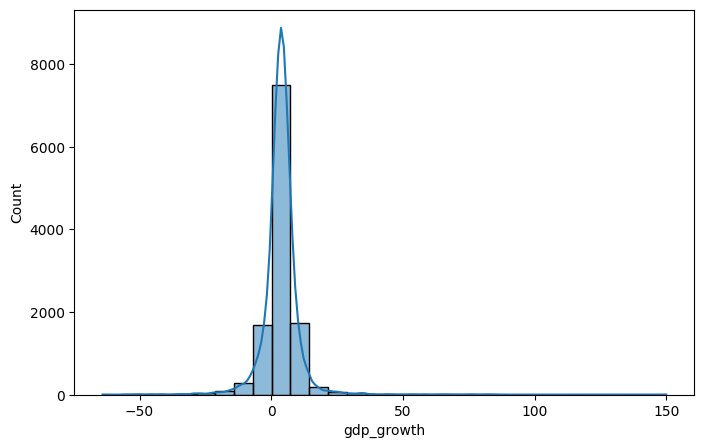

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['gdp_growth'], bins = 30, kde = True)
plt.show()

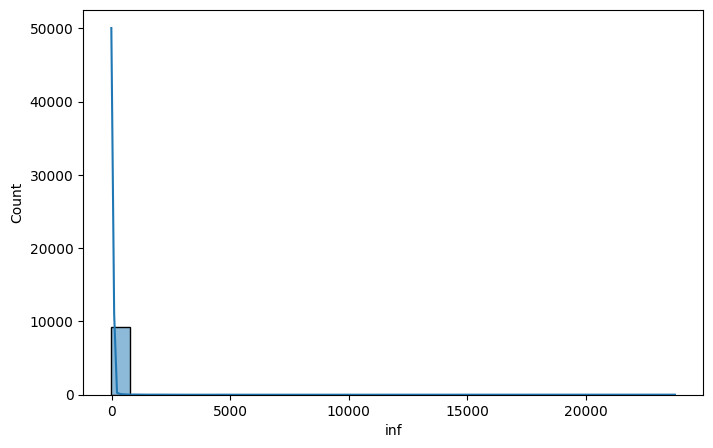

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["inf"].dropna(), bins=30, kde=True)
plt.show()

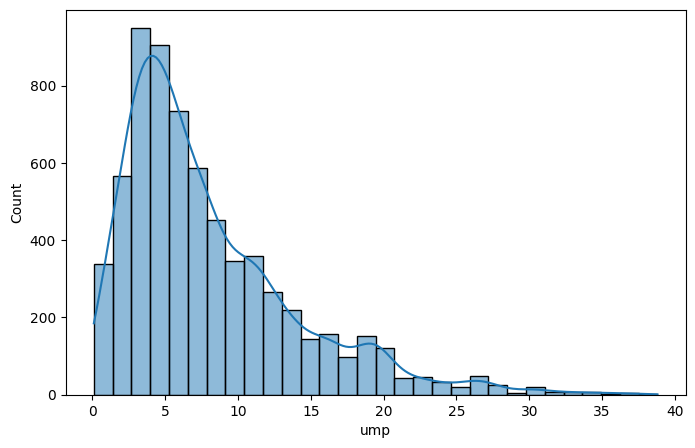

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["ump"].dropna(), bins=30, kde=True)
plt.show()

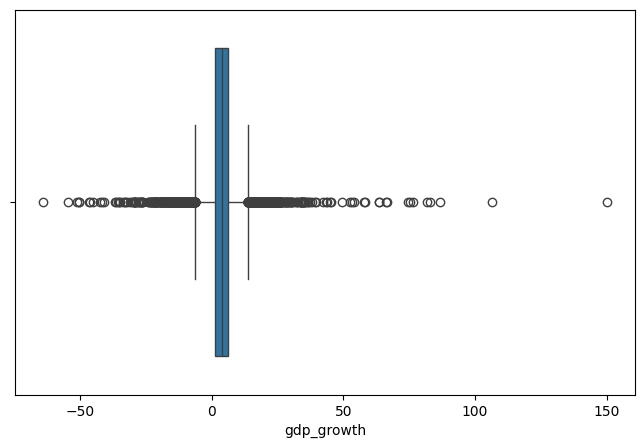

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["gdp_growth"])
plt.show()

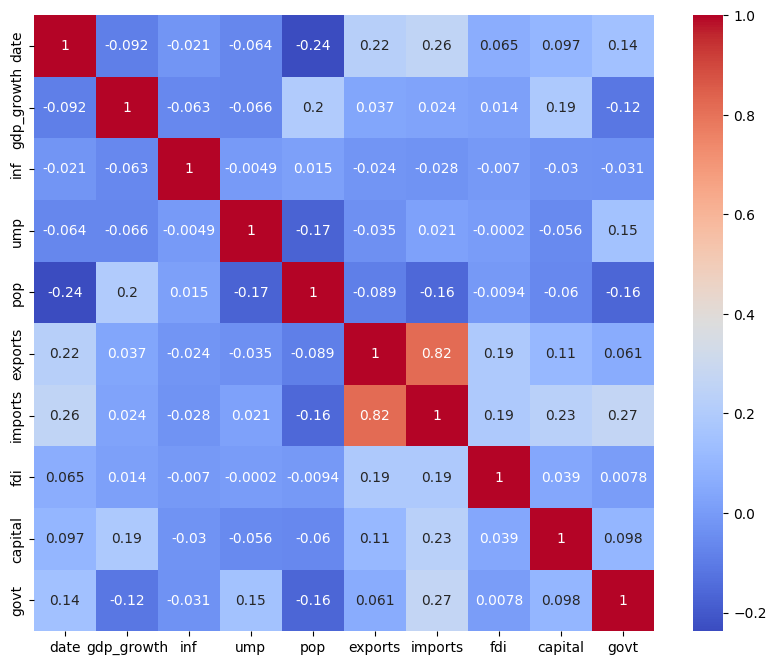

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

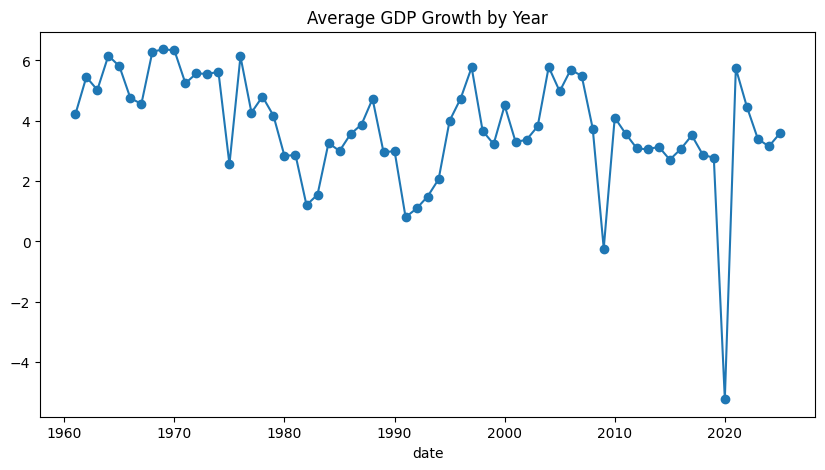

In [16]:
yearly = df.groupby("date")["gdp_growth"].mean()

yearly.plot(figsize=(10,5), marker="o")
plt.title("Average GDP Growth by Year")
plt.show()

# Impact of COVID on economies

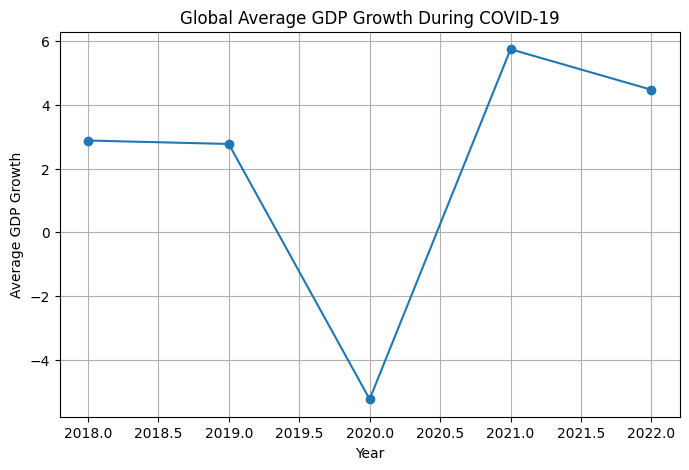

In [17]:
covid = df[df["date"].isin([2018, 2019, 2020, 2021, 2022])]

covid = covid.groupby("date")["gdp_growth"].mean()

plt.figure(figsize=(8,5))
plt.plot(covid.index, covid.values, marker="o")
plt.title("Global Average GDP Growth During COVID-19")
plt.xlabel("Year")
plt.ylabel("Average GDP Growth")
plt.grid(True)
plt.show()

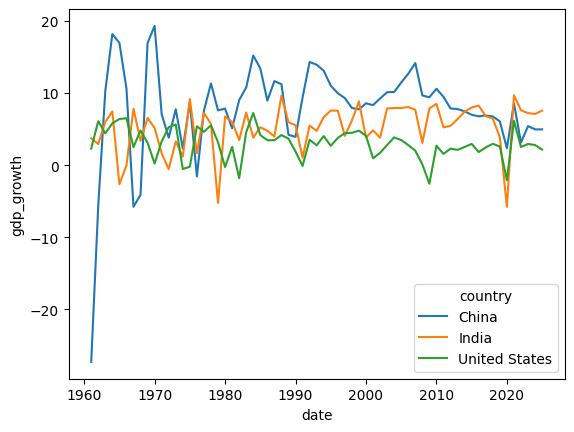

In [18]:
countries = ["India","China","United States"]

temp = df[df["country"].isin(countries)]

sns.lineplot(data=temp,x="date",y="gdp_growth",hue="country")
plt.show()

# Observation
## a) Dataset has 17490 rows and 12 features.
## b) No duplicate rows found.
## c) Unemployment has 53% missing values.
## d) GDP Growth shows outliers.
## e) GDP Growth has weak linear correlation with indiviudal predictors.
## f) COVID period shows a noticeable decline in the average GDP growth.